# Assignment 6: Apply NB

<ol>
    <li><strong>Apply Multinomial NB on these feature sets</strong>
        <ul>
            <li><font color='red'>Set 1</font>: categorical, numerical features + preprocessed_eassay (BOW)</li>
            <li><font color='red'>Set 2</font>: categorical, numerical features + preprocessed_eassay (TFIDF)</li>
        </ul>
    </li>
    <li><strong>The hyper paramter tuning(find best alpha:smoothing parameter)</strong>
        <ul>
    <li>Find the best hyper parameter which will give the maximum <a href='https://www.appliedaicourse.com/course/applied-ai-course-online/lessons/receiver-operating-characteristic-curve-roc-curve-and-auc-1/'>AUC</a> value</li>
    <li>find the best hyper paramter using k-fold cross validation(use GridsearchCV or RandomsearchCV)/simple cross validation data (write for loop to iterate over hyper parameter values)</li>
    <li></li>
        </ul>
    </li>
    <li>
    <strong>Representation of results</strong>
        <ul>
    <li>You need to plot the performance of model both on train data and cross validation data for each hyper parameter, like shown in the figure
    <img src='https://i.imgur.com/hUv6aEy.jpg' width=300px></li>
    <li>Once after you found the best hyper parameter, you need to train your model with it, and find the AUC on test data and plot the ROC curve on both train and test.
    <img src='https://i.imgur.com/wMQDTFe.jpg' width=300px></li>
    <li>Along with plotting ROC curve, you need to print the <a href='https://www.appliedaicourse.com/course/applied-ai-course-online/lessons/confusion-matrix-tpr-fpr-fnr-tnr-1/'>confusion matrix</a> with predicted and original labels of test data points
    <img src='https://i.imgur.com/IdN5Ctv.png' width=300px></li>
        </ul>
    </li>
    <li>
fine the top 20 features from either from feature <font color='red'>Set 1</font> or feature <font color='red'>Set 2</font> using absolute values of `feature_log_prob_ ` parameter of `MultinomialNB` 
(https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html) and print their corresponding feature names
    </li>
    <li>You need to summarize the results at the end of the notebook, summarize it in the table format
        <img src='http://i.imgur.com/YVpIGGE.jpg' width=400px>
    </li>
</ol>

<h1>2. Naive Bayes </h1>

## 1.1 Loading Data

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")
import pandas
data_donor_choose = pandas.read_csv('preprocessed_data.csv')
print(data_donor_choose.shape)

(109248, 9)


In [2]:
maj_class = data_donor_choose[data_donor_choose['project_is_approved'] == 1]
min_class = data_donor_choose[data_donor_choose['project_is_approved'] == 0]
print(maj_class.shape,min_class.shape)                                          #data set is highly imbalance so upsampling is necessary

(92706, 9) (16542, 9)


# Upsampling the dataset

In [3]:
from sklearn.utils import resample
Upsampled_min_class = resample(min_class, replace = True,                   
                                      n_samples = len(maj_class),  
                                      random_state = 123                
                                    )
data_donor_choose = pandas.concat([maj_class, Upsampled_min_class])
Y= data_donor_choose['project_is_approved']
X= data_donor_choose.drop(['project_is_approved'], axis=1)


<h2>1.2 Splitting data into Train and cross validation(or test): Stratified Sampling</h2>

In [4]:
# please write all the code with proper documentation, and proper titles for each subsection
# go through documentations and blogs before you start coding
# first figure out what to do, and then think about how to do.
# reading and understanding error messages will be very much helpfull in debugging your code
# when you plot any graph make sure you use 
    # a. Title, that describes your plot, this will be very helpful to the reader
    # b. Legends if needed
    # c. X-axis label
    # d. Y-axis label
from sklearn.model_selection import train_test_split 
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, stratify=Y) 
X_train, X_cross_val, Y_train, Y_cross_val = train_test_split(X_train, Y_train, test_size=0.33, stratify=Y_train)

print("Datapoints of Training Set : ", len(X_train))
print("Datapoints of CV Set : ", len(X_cross_val))
print("Datapoints of Test Set : ", len(X_test))    

Datapoints of Training Set :  83231
Datapoints of CV Set :  40995
Datapoints of Test Set :  61186


<h2>1.3 Make Data Model Ready: encoding eassay, and project_title</h2>

# vectorizing eassy using BOW

In [192]:
# please write all the code with proper documentation, and proper titles for each subsection
# go through documentations and blogs before you start coding
# first figure out what to do, and then think about how to do.
# reading and understanding error messages will be very much helpfull in debugging your code
# make sure you featurize train and test data separatly

# when you plot any graph make sure you use 
    # a. Title, that describes your plot, this will be very helpful to the reader
    # b. Legends if needed
    # c. X-axis label
    # d. Y-axis label
from sklearn.feature_extraction.text import CountVectorizer    
count_vectorizer = CountVectorizer(min_df = 10)
count_vectorizer.fit(X_train['essay'].values)
x_train_essay_bow = count_vectorizer.transform(X_train['essay'].values)
x_cross_val_essay_bow = count_vectorizer.transform(X_cross_val['essay'].values)
x_test_essay_bow = count_vectorizer.transform(X_test['essay'].values)

print( "vectorizations")
print(x_train_essay_bow.shape, Y_train.shape)
print(x_cross_val_essay_bow.shape, Y_cross_val.shape)
print(x_test_essay_bow.shape, Y_test.shape)    

vectorizations
(83231, 14902) (83231,)
(40995, 14902) (40995,)
(61186, 14902) (61186,)


# vectorizing essay using TF-IDF

In [193]:
from sklearn.feature_extraction.text import TfidfVectorizer
tf_idf_vect = TfidfVectorizer(min_df=10)
tf_idf_vect.fit(X_train['essay'].values)

# using the fitted model to convert text to vector

x_train_essay_tfidf = tf_idf_vect.transform(X_train['essay'].values)
x_cross_val_essay_tfidf = tf_idf_vect.transform(X_cross_val['essay'].values)
x_test_essay_tfidf = tf_idf_vect.transform(X_test['essay'].values)

print("vectorizations")
print(x_train_essay_tfidf.shape, Y_train.shape)
print(x_cross_val_essay_tfidf.shape, Y_cross_val.shape)
print(x_test_essay_tfidf.shape, Y_test.shape)

vectorizations
(83231, 14902) (83231,)
(40995, 14902) (40995,)
(61186, 14902) (61186,)


<h2>1.4 Make Data Model Ready: encoding numerical, categorical features</h2>

# encoding school state

In [6]:
len(X_train['school_state'].unique())

51

In [7]:
# please write all the code with proper documentation, and proper titles for each subsection
# go through documentations and blogs before you start coding 
# first figure out what to do, and then think about how to do.
# reading and understanding error messages will be very much helpfull in debugging your code
# make sure you featurize train and test data separatly

# when you plot any graph make sure you use 
    # a. Title, that describes your plot, this will be very helpful to the reader
    # b. Legends if needed
    # c. X-axis label
    # d. Y-axis label
print(data_donor_choose.columns)
from sklearn.feature_extraction.text import CountVectorizer

school_state = CountVectorizer()
school_state.fit(X_train['school_state'].values)

# we use the fitted CountVectorizer to convert the text to vector

x_train_school_state = school_state.transform(X_train['school_state'].values)
x_cross_val_school_state = school_state.transform(X_cross_val['school_state'].values)
x_test_school_state = school_state.transform(X_test['school_state'].values)

print(x_train_school_state.shape, Y_train.shape)
print(x_cross_val_school_state.shape, Y_cross_val.shape)
print(x_cross_val_school_state.shape, Y_test.shape)    

Index(['school_state', 'teacher_prefix', 'project_grade_category',
       'teacher_number_of_previously_posted_projects', 'project_is_approved',
       'clean_categories', 'clean_subcategories', 'essay', 'price'],
      dtype='object')
(83231, 51) (83231,)
(40995, 51) (40995,)
(40995, 51) (61186,)


# encoding teacher prefix

In [195]:
print(data_donor_choose.columns)
from sklearn.feature_extraction.text import CountVectorizer

teacher_prefix = CountVectorizer()
teacher_prefix.fit(X_train['teacher_prefix'].values)

# we use the fitted CountVectorizer to convert the text to vector

x_train_teacher_prefix = teacher_prefix.transform(X_train['teacher_prefix'].values)
x_cross_val_teacher_prefix = teacher_prefix.transform(X_cross_val['teacher_prefix'].values)
x_test_teacher_prefix = teacher_prefix.transform(X_test['teacher_prefix'].values)

print(x_train_teacher_prefix.shape, Y_train.shape)
print(x_cross_val_teacher_prefix.shape, Y_cross_val.shape)
print(x_cross_val_teacher_prefix.shape, Y_test.shape)  

Index(['school_state', 'teacher_prefix', 'project_grade_category',
       'teacher_number_of_previously_posted_projects', 'project_is_approved',
       'clean_categories', 'clean_subcategories', 'essay', 'price'],
      dtype='object')
(83231, 5) (83231,)
(40995, 5) (40995,)
(40995, 5) (61186,)


# encoding project grade category

In [196]:
print(data_donor_choose.columns)
from sklearn.feature_extraction.text import CountVectorizer

project_grade_category = CountVectorizer()
project_grade_category.fit(X_train['project_grade_category'].values)

# we use the fitted CountVectorizer to convert the text to vector

x_train_project_grade_category = project_grade_category.transform(X_train['project_grade_category'].values)
x_cross_val_project_grade_category = project_grade_category.transform(X_cross_val['project_grade_category'].values)
x_test_project_grade_category = project_grade_category.transform(X_test['project_grade_category'].values)

print(x_train_project_grade_category.shape, Y_train.shape)
print(x_cross_val_project_grade_category.shape, Y_cross_val.shape)
print(x_cross_val_project_grade_category.shape, Y_test.shape)  

Index(['school_state', 'teacher_prefix', 'project_grade_category',
       'teacher_number_of_previously_posted_projects', 'project_is_approved',
       'clean_categories', 'clean_subcategories', 'essay', 'price'],
      dtype='object')
(83231, 4) (83231,)
(40995, 4) (40995,)
(40995, 4) (61186,)


# encoding clean categories

In [197]:
print(data_donor_choose.columns)
from sklearn.feature_extraction.text import CountVectorizer

clean_categories = CountVectorizer()
clean_categories.fit(X_train['clean_categories'].values)

# we use the fitted CountVectorizer to convert the text to vector

x_train_clean_categories = clean_categories.transform(X_train['clean_categories'].values)
x_cross_val_clean_categories = clean_categories.transform(X_cross_val['clean_categories'].values)
x_test_clean_categories = clean_categories.transform(X_test['clean_categories'].values)

print(x_train_clean_categories.shape, Y_train.shape)
print(x_cross_val_clean_categories.shape, Y_cross_val.shape)
print(x_cross_val_clean_categories.shape, Y_test.shape)

Index(['school_state', 'teacher_prefix', 'project_grade_category',
       'teacher_number_of_previously_posted_projects', 'project_is_approved',
       'clean_categories', 'clean_subcategories', 'essay', 'price'],
      dtype='object')
(83231, 9) (83231,)
(40995, 9) (40995,)
(40995, 9) (61186,)


# encoding clean_subcategories

In [198]:
print(data_donor_choose.columns)
from sklearn.feature_extraction.text import CountVectorizer

clean_subcategories = CountVectorizer()
clean_subcategories.fit(X_train['clean_subcategories'].values)

# we use the fitted CountVectorizer to convert the text to vector

x_train_clean_subcategories = clean_subcategories.transform(X_train['clean_subcategories'].values)
x_cross_val_clean_subcategories = clean_subcategories.transform(X_cross_val['clean_subcategories'].values)
x_test_clean_subcategories = clean_subcategories.transform(X_test['clean_subcategories'].values)

print(x_train_clean_subcategories.shape, Y_train.shape)
print(x_cross_val_clean_subcategories.shape, Y_cross_val.shape)
print(x_cross_val_clean_subcategories.shape, Y_test.shape)

Index(['school_state', 'teacher_prefix', 'project_grade_category',
       'teacher_number_of_previously_posted_projects', 'project_is_approved',
       'clean_categories', 'clean_subcategories', 'essay', 'price'],
      dtype='object')
(83231, 30) (83231,)
(40995, 30) (40995,)
(40995, 30) (61186,)


# numerical features price

In [199]:
from sklearn.preprocessing import Normalizer
normalizer = Normalizer()

normalizer.fit(X_train['price'].values.reshape(1, -1))

x_train_price = normalizer.transform(X_train['price'].values.reshape(1, -1)).T
x_cross_val_price = normalizer.transform(X_cross_val['price'].values.reshape(1, -1)).T
x_test_price = normalizer.transform(X_test['price'].values.reshape(1, -1)).T

print(x_train_price.shape, Y_train.shape)
print(x_cross_val_price.shape, Y_cross_val.shape)
print(x_test_price.shape, Y_test.shape)

(83231, 1) (83231,)
(40995, 1) (40995,)
(61186, 1) (61186,)


# numerical feature  teacher_number_of_previously_posted_projects

In [200]:
from sklearn.preprocessing import Normalizer
normalizer = Normalizer()

normalizer.fit(X_train['teacher_number_of_previously_posted_projects'].values.reshape(1, -1))

x_train_teacher_posted_prev = normalizer.transform(X_train['teacher_number_of_previously_posted_projects'].values.reshape(1, -1)).T
x_cross_val_teacher_posted_prev = normalizer.transform(X_cross_val['teacher_number_of_previously_posted_projects'].values.reshape(1, -1)).T
x_test_teacher_posted_prev = normalizer.transform(X_test['teacher_number_of_previously_posted_projects'].values.reshape(1, -1)).T

print(x_train_teacher_posted_prev.shape, Y_train.shape)
print(x_cross_val_teacher_posted_prev.shape, Y_cross_val.shape)
print(x_test_teacher_posted_prev.shape, Y_test.shape)

(83231, 1) (83231,)
(40995, 1) (40995,)
(61186, 1) (61186,)


<h2>1.5 Appling NB on different kind of featurization as mentioned in the instructions</h2>

<br>Apply NB on different kind of featurization as mentioned in the instructions
<br> For Every model that you work on make sure you do the step 2 and step 3 of instrucations

# summing all features of bag of words

In [201]:
from scipy.sparse import hstack
all_X_train_bow_sample = hstack((x_train_essay_bow,x_train_school_state,x_train_teacher_prefix,x_train_project_grade_category,x_train_clean_categories,x_train_clean_subcategories,
                                 x_train_price,x_train_teacher_posted_prev)).tocsr()
all_X_test_bow_sample =  hstack((x_test_essay_bow,x_test_school_state,x_test_teacher_prefix,x_test_project_grade_category,x_test_clean_categories,x_test_clean_subcategories,
                                 x_test_price,x_test_teacher_posted_prev)).tocsr()
all_X_cross_val_bow_sample = hstack((x_cross_val_essay_bow,x_cross_val_school_state,x_cross_val_teacher_prefix,x_cross_val_project_grade_category,x_cross_val_clean_categories,x_cross_val_clean_subcategories,
                                 x_cross_val_price,x_cross_val_teacher_posted_prev)).tocsr()
 

# Implementing naive bayes on set 1 features

In [202]:
# please write all the code with proper documentation, and proper titles for each subsection
# go through documentations and blogs before you start coding
# first figure out what to do, and then think about how to do.
# reading and understanding error messages will be very much helpfull in debugging your code
# when you plot any graph make sure you use 
    # a. Title, that describes your plot, this will be very helpful to the reader
    # b. Legends if needed
    # c. X-axis label
    # d. Y-axis label
  
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB

tuning_parameters = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]}

#using GridSearchCV

model = GridSearchCV(MultinomialNB(), tuning_parameters, scoring = 'roc_auc', cv = 5)
model.fit(all_X_train_bow_sample, Y_train)
print(model)
print(model.best_estimator_)
print(model.score(all_X_cross_val_bow_sample, Y_cross_val))    

GridSearchCV(cv=5, error_score=nan,
             estimator=MultinomialNB(alpha=1.0, class_prior=None,
                                     fit_prior=True),
             iid='deprecated', n_jobs=None,
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000,
                                   10000]},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=False,
             scoring='roc_auc', verbose=0)
MultinomialNB(alpha=0.0001, class_prior=None, fit_prior=True)
0.7511862869418057


In [203]:
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import numpy as np
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix  

In [204]:
alpha_list = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
tr_auc = []
cross_val_auc = []

for alp in tqdm(alpha_list):
  bow_sample = MultinomialNB(alpha=alp)
  bow_sample.fit(all_X_train_bow_sample, Y_train)

  Y_train_pred = bow_sample.predict_proba(all_X_train_bow_sample)[:, 1]
  Y_cross_val_pred = bow_sample.predict_proba(all_X_cross_val_bow_sample)[:, 1]

  tr_auc.append(roc_auc_score(Y_train, Y_train_pred))
  cross_val_auc.append(roc_auc_score(Y_cross_val, Y_cross_val_pred))




  0%|                                                                                            | 0/9 [00:00<?, ?it/s]


 11%|█████████▎                                                                          | 1/9 [00:00<00:07,  1.13it/s]


 22%|██████████████████▋                                                                 | 2/9 [00:01<00:05,  1.18it/s]


 33%|████████████████████████████                                                        | 3/9 [00:02<00:04,  1.29it/s]


 44%|█████████████████████████████████████▎                                              | 4/9 [00:02<00:03,  1.35it/s]


 56%|██████████████████████████████████████████████▋                                     | 5/9 [00:03<00:02,  1.35it/s]


 67%|████████████████████████████████████████████████████████                            | 6/9 [00:04<00:02,  1.31it/s]


 78%|█████████████████████████████████████████████████████████████████▎                  | 7/9 [00:05<00:01,  1.24it/s]


 89%|████████████████

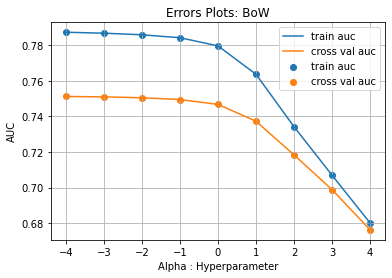

In [205]:
plt.plot(np.log10(alpha_list), tr_auc, label = 'train auc')
plt.plot(np.log10(alpha_list), cross_val_auc, label = 'cross val auc')

plt.scatter(np.log10(alpha_list), tr_auc, label = 'train auc')
plt.scatter(np.log10(alpha_list), cross_val_auc, label = 'cross val auc')

plt.legend()
plt.xlabel("Alpha : Hyperparameter")
plt.ylabel("AUC")
plt.title("Errors Plots: BoW")
plt.grid()
plt.show()

In [206]:
optimal_alpha = alpha_list[cross_val_auc.index(max(cross_val_auc))]
print(optimal_alpha)
print(max(cross_val_auc))
bow_sample = MultinomialNB(alpha = optimal_alpha)

0.0001
0.7511862869418057


# Observation


The best alpha is 0.001
andd AUC score is 0.7511(approx)

# Training model on best alpha

In [207]:
bow_sample.fit(all_X_train_bow_sample, Y_train)

Y_train_pred = bow_sample.predict_proba(all_X_train_bow_sample)[:, 1]
Y_test_pred = bow_sample.predict_proba(all_X_test_bow_sample)[:, 1]

train_false_positive_rate, train_true_positive_rate , train_thresholds = roc_curve(Y_train, Y_train_pred)
test_false_positive_rate, test_true_positive_rate, test_thresholds = roc_curve(Y_test, Y_test_pred)

best_positive_features = bow_sample.feature_log_prob_[0, :].argsort()
top_20 = best_positive_features[:20]

print("Train AUC Score: ", auc(train_false_positive_rate, train_true_positive_rate))
print("Test AUC Score: ", auc(test_false_positive_rate, test_true_positive_rate))

Train AUC Score:  0.7872731272706646
Test AUC Score:  0.7504053786944862


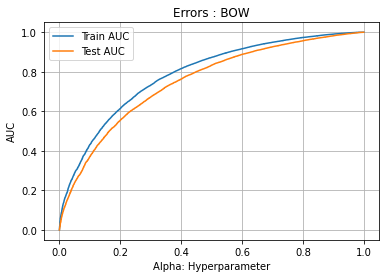

In [208]:
plt.plot(train_false_positive_rate, train_true_positive_rate, label = "Train AUC")
plt.plot(test_false_positive_rate, test_true_positive_rate, label = "Test AUC")

plt.legend()
plt.xlabel("Alpha: Hyperparameter")
plt.ylabel("AUC")
plt.title("Errors : BOW")
plt.grid()
plt.show()

#    Confusion matrix

In [212]:
# we are writing our own function for predict, with defined thresould
# we will pick a threshold that will give the least fpr
def label_conversion(proba, threshold, fpr, tpr):
  
    # (tpr*(1-fpr)) will be maximum if your fpr is very low and tpr is very high
    t = threshold[np.argmax(tpr*(1-fpr))]
    predictions = []
    for i in proba:
        if i>=t:
            predictions.append(1)
        else:
            predictions.append(0)
    return predictions

conf_matrix = confusion_matrix(Y_test, label_conversion(Y_test_pred, test_thresholds, test_false_positive_rate, test_true_positive_rate))


[Text(0, 0.5, 'negative'), Text(0, 1.5, 'positive')]

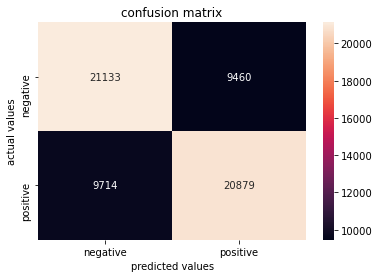

In [213]:
import seaborn as sns
import matplotlib.pyplot as plt

heat_map = plt.subplot()
sns.heatmap(conf_matrix, annot = True, ax = heat_map, fmt= 'g')

heat_map.set_ylabel("actual values")
heat_map.set_xlabel("predicted values")
heat_map.set_title("confusion matrix")
heat_map.xaxis.set_ticklabels(['negative', 'positive'])
heat_map.yaxis.set_ticklabels(['negative', 'positive'])

# summing all the point of TFIDF vector

In [214]:
from scipy.sparse import hstack
all_X_train_tfidf_sample = hstack((x_train_essay_tfidf,x_train_school_state,x_train_teacher_prefix,x_train_project_grade_category,x_train_clean_categories,x_train_clean_subcategories,
                                 x_train_price,x_train_teacher_posted_prev)).tocsr()
all_X_test_tfidf_sample =  hstack((x_test_essay_tfidf,x_test_school_state,x_test_teacher_prefix,x_test_project_grade_category,x_test_clean_categories,x_test_clean_subcategories,
                                 x_test_price,x_test_teacher_posted_prev)).tocsr()
all_X_cross_val_tfidf_sample = hstack((x_cross_val_essay_tfidf,x_cross_val_school_state,x_cross_val_teacher_prefix,x_cross_val_project_grade_category,x_cross_val_clean_categories,x_cross_val_clean_subcategories,
                                 x_cross_val_price,x_cross_val_teacher_posted_prev)).tocsr()

# Insert naive bayes on set 2 features

In [215]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB

tuning_parameters = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]}

#using GridSearchCV

model = GridSearchCV(MultinomialNB(), tuning_parameters, scoring = 'roc_auc', cv = 5)
model.fit(all_X_train_tfidf_sample, Y_train)
print(model)
print(model.best_estimator_)
print(model.score(all_X_cross_val_tfidf_sample, Y_cross_val))    

GridSearchCV(cv=5, error_score=nan,
             estimator=MultinomialNB(alpha=1.0, class_prior=None,
                                     fit_prior=True),
             iid='deprecated', n_jobs=None,
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000,
                                   10000]},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=False,
             scoring='roc_auc', verbose=0)
MultinomialNB(alpha=0.0001, class_prior=None, fit_prior=True)
0.7299170710774134


In [216]:
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import numpy as np
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix

In [217]:
alpha_list = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
tr_auc = []
cross_val_auc = []

for alp in tqdm(alpha_list):
  tfidf_sample = MultinomialNB(alpha=alp)
  tfidf_sample.fit(all_X_train_tfidf_sample, Y_train)

  Y_train_pred = tfidf_sample.predict_proba(all_X_train_tfidf_sample)[:, 1]
  Y_cross_val_pred = tfidf_sample.predict_proba(all_X_cross_val_tfidf_sample)[:, 1]

  tr_auc.append(roc_auc_score(Y_train, Y_train_pred))
  cross_val_auc.append(roc_auc_score(Y_cross_val, Y_cross_val_pred))




  0%|                                                                                            | 0/9 [00:00<?, ?it/s]


 11%|█████████▎                                                                          | 1/9 [00:00<00:06,  1.22it/s]


 22%|██████████████████▋                                                                 | 2/9 [00:01<00:05,  1.25it/s]


 33%|████████████████████████████                                                        | 3/9 [00:02<00:04,  1.27it/s]


 44%|█████████████████████████████████████▎                                              | 4/9 [00:03<00:03,  1.26it/s]


 56%|██████████████████████████████████████████████▋                                     | 5/9 [00:04<00:03,  1.19it/s]


 67%|████████████████████████████████████████████████████████                            | 6/9 [00:04<00:02,  1.19it/s]


 78%|█████████████████████████████████████████████████████████████████▎                  | 7/9 [00:05<00:01,  1.20it/s]


 89%|████████████████

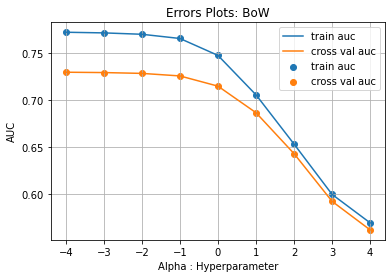

In [218]:
plt.plot(np.log10(alpha_list), tr_auc, label = 'train auc')
plt.plot(np.log10(alpha_list), cross_val_auc, label = 'cross val auc')

plt.scatter(np.log10(alpha_list), tr_auc, label = 'train auc')
plt.scatter(np.log10(alpha_list), cross_val_auc, label = 'cross val auc')

plt.legend()
plt.xlabel("Alpha : Hyperparameter")
plt.ylabel("AUC")
plt.title("Errors Plots: BoW")
plt.grid()
plt.show()

# Training model on best alpha 

In [219]:
optimal_alpha = alpha_list[cross_val_auc.index(max(cross_val_auc))]
print(optimal_alpha)
print(max(cross_val_auc))
tfidf_sample = MultinomialNB(alpha= optimal_alpha)
tfidf_sample.fit(all_X_train_tfidf_sample, Y_train)

Y_train_pred = tfidf_sample.predict_proba(all_X_train_tfidf_sample)[:, 1]
Y_test_pred = tfidf_sample.predict_proba(all_X_test_tfidf_sample)[:, 1]

train_false_positive_rate, train_true_positive_rate, train_thresholds = roc_curve(Y_train, Y_train_pred)
test_false_positive_rate, test_true_positive_rate, test_thresholds = roc_curve(Y_test, Y_test_pred)

print("Train AUC Score: ", auc(train_false_positive_rate, train_true_positive_rate))
print("Test AUC Score: ", auc(test_false_positive_rate, test_true_positive_rate))

0.0001
0.7299170710774134
Train AUC Score:  0.7724180486686998
Test AUC Score:  0.7308590181033616


# Observation

The best alpha is 0.001
and AUC score is 0.7299

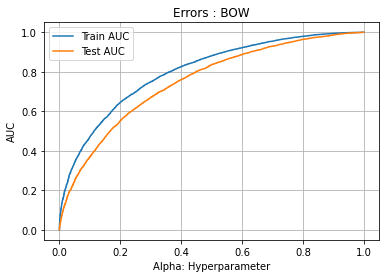

In [163]:
plt.plot(train_false_positive_rate, train_true_positive_rate, label = "Train AUC")
plt.plot(test_false_positive_rate, test_true_positive_rate, label = "Test AUC")

plt.legend()
plt.xlabel("Alpha: Hyperparameter")
plt.ylabel("AUC")
plt.title("Errors : BOW")
plt.grid()
plt.show()

# Confusion matrix for TFIDF vectorizer on test data

In [220]:
# we are writing our own function for predict, with defined thresould
# we will pick a threshold that will give the least fpr

def label_conversion(proba, threshold, fpr, tpr):
  
    # (tpr*(1-fpr)) will be maximum if your fpr is very low and tpr is very high
    t = threshold[np.argmax(tpr*(1-fpr))]
    predictions = []
    for i in proba:
        if i>=t:
            predictions.append(1)
        else:
            predictions.append(0)
    return predictions

conf_matrix = confusion_matrix(Y_test, label_conversion(Y_test_pred, test_thresholds, test_false_positive_rate, test_true_positive_rate))


[Text(0, 0.5, 'negative'), Text(0, 1.5, 'positive')]

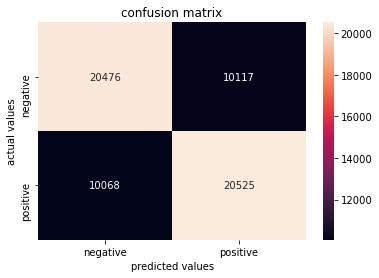

In [221]:
import seaborn as sns
import matplotlib.pyplot as plt

heat_map = plt.subplot()
sns.heatmap(conf_matrix, annot = True, ax = heat_map, fmt= 'g')

heat_map.set_ylabel("actual values")
heat_map.set_xlabel("predicted values")
heat_map.set_title("confusion matrix")
heat_map.xaxis.set_ticklabels(['negative', 'positive'])
heat_map.yaxis.set_ticklabels(['negative', 'positive'])

# TOP 20 features of BOW

In [222]:
#https://stackoverflow.com/questions/50526898/how-to-get-feature-importance-in-naive-bayes

feature_of_bag_of_words= []
feature_of_bag_of_words.extend(count_vectorizer.get_feature_names())
feature_of_bag_of_words.extend(school_state.get_feature_names())
feature_of_bag_of_words.extend(teacher_prefix.get_feature_names())
feature_of_bag_of_words.extend(project_grade_category.get_feature_names())
feature_of_bag_of_words.extend(clean_categories.get_feature_names())
feature_of_bag_of_words.extend(clean_subcategories.get_feature_names())
print(len(feature_of_bag_of_words))

15001


In [223]:
zero_class_sorted = bow_sample.feature_log_prob_[0, :].argsort()[::-1][:len(feature_of_bag_of_words)]
one_class_sorted = bow_sample.feature_log_prob_[1, :].argsort()[::-1][:len(feature_of_bag_of_words)]   

In [224]:
print('Top 20 features from zero class:')
print(np.take(feature_of_bag_of_words, zero_class_sorted[:20]))
print('-*'*100)
print('Top 20 features from one class:')
print(np.take(feature_of_bag_of_words, one_class_sorted[:20]))

Top 20 features from zero class:
['students' 'school' 'learning' 'my' 'classroom' 'not' 'learn' 'they'
 'help' 'the' 'nannan' 'many' 'we' 'need' 'work' 'come' 'reading' 'love'
 'materials' 'skills']
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
Top 20 features from one class:
['students' 'school' 'my' 'learning' 'classroom' 'the' 'they' 'not'
 'learn' 'help' 'many' 'nannan' 'we' 'need' 'reading' 'work' 'use' 'love'
 'day' 'able']


# Summary

In [225]:
from prettytable import PrettyTable

naive_table = PrettyTable()
naive_table.field_names = ['Vectorizer Algorithm', "Best Alpha", "AUC Score"]

naive_table.add_row(["BOW", "0.0001", "0.7511"])
naive_table.add_row(["TFIDF", "0.0001", "0.7299"])

print(naive_table)

+----------------------+------------+-----------+
| Vectorizer Algorithm | Best Alpha | AUC Score |
+----------------------+------------+-----------+
|         BOW          |   0.0001   |   0.7511  |
|        TFIDF         |   0.0001   |   0.7299  |
+----------------------+------------+-----------+
